## Assignment 2: $k$ Nearest Neighbor

### Do any four.

In [1]:
! git clone https://github.com/dishidhak/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 109 (delta 37), reused 30 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (109/109), 657.47 KiB | 16.44 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions.
**1. What is the difference between regression and classification?**

Regression predicts a continuous numerical value (e.g., house price).Classification predicts a discrete category or label (e.g., spam vs. not spam).

**2. What is a confusion table/matrix? What does it help us understand about a model's performance?**

A confusion matrix is a table that compares predicted labels with true labels. It shows True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN). It helps us understand what types of errors a model is making, not just how often it is correct.

**3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?**

Accuracy is the proportion of correct predictions out of total predictions. Accuracy can be misleading with imbalanced data. For example, if 95% of cases are negative, a model that always predicts negative will have 95% accuracy but be useless.



**4. What does the root mean squared error quantify about a particular model?**

Root Mean Squared Error (RMSE) measures the average magnitude of prediction errors in regression. It penalizes large errors more heavily because of squaring. Lower RMSE means better predictive performance.


**5. What are overfitting and underfitting?**

Overfitting: Model learns noise in training data. It will have very low training error but poor test performance.

Underfitting: Model is too simple and has high error on both training and test data.

Good models balance bias and variance.


**6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?**


**7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**

Class Label Prediction are simple and easy to interpret, useful when a hard decision is required, but doesn’t show confidence level.

Probability Distribution Prediction provides uncertainty information, allows threshold tuning (important in medical/fraud cases), but is slightly more complex to interpret.




**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/land_mines.csv")

df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [3]:
df.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [4]:
df['mine_type'].value_counts()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


The data is relatively balanced across mine types. This is ideal for k-NN because accuracy won’t be artificially inflated, no class dominates, stratified splitting will work well.


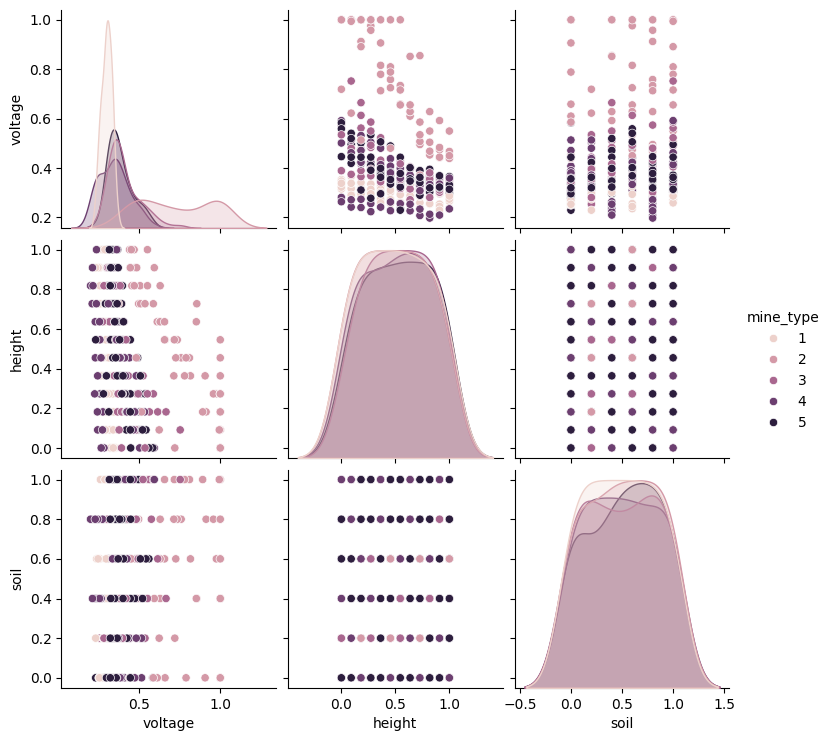

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="mine_type")
plt.show()

The pairwise scatterplots show substantial overlap among the five mine types across voltage, height, and soil. Mine type 2 appears somewhat separable due to higher voltage values, but the remaining classes exhibit significant overlap in feature space. Height and soil individually do not strongly distinguish the classes. This suggests that a k-NN classifier may achieve moderate accuracy, but confusion between similar mine types is likely.

In [6]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

# 50/50 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    stratify=y,      # ensures class balance in both sets
    random_state=42  # reproducibility
)

# Check sizes
print("Training size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Check class balance in each set
print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training size: 169
Test size: 169

Training class distribution:
mine_type
1    35
2    35
3    33
5    33
4    33
Name: count, dtype: int64

Test class distribution:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


The dataset was split 50/50 into training and test sets using stratified sampling to preserve class proportions. Each set contains 169 observations. The distribution of mine types remains balanced across both sets, ensuring that no class is over- or underrepresented. This balanced split allows for a fair evaluation of model performance.

Best k: 1
Best test accuracy: 0.5088757396449705


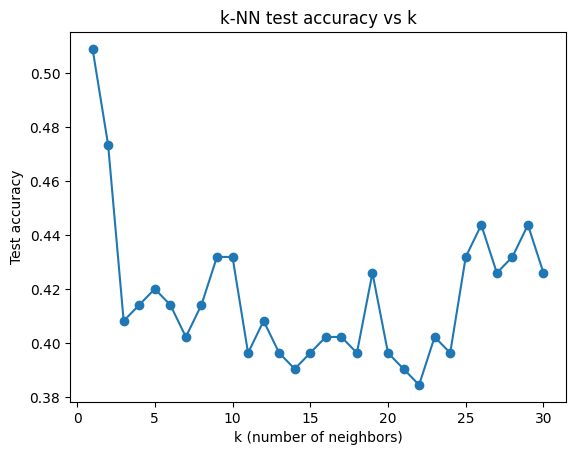

KNeighborsClassifier(n_neighbors=1)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 1) Scale features (k-NN is distance-based, so scaling matters)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same scaling to test

# 2) Try a range of k values and track test accuracy
k_values = range(1, 31)
accs = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    accs.append(accuracy_score(y_test, y_pred_k))

# 3) Choose the k with the highest test accuracy
best_k = k_values[int(np.argmax(accs))]
best_acc = max(accs)

print("Best k:", best_k)
print("Best test accuracy:", best_acc)

# Plot accuracy vs k to justify the choice visually
plt.plot(list(k_values), accs, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Test accuracy")
plt.title("k-NN test accuracy vs k")
plt.show()

# 4) Train the final (best) model
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

I trained k-NN classifiers for values of k ranging from 1 to 30 and evaluated performance using accuracy on the test set. The highest test accuracy (approximately 50.9%) was achieved at k=1. Therefore, I selected k=1 for the final model. Although larger values of k reduce variance, they produced lower accuracy in this case. The relatively modest accuracy overall suggests substantial overlap among the mine types in feature space.

Confusion Matrix:
[[22  0  3  3  8]
 [ 0 32  0  3  0]
 [ 7  0 10  9  7]
 [ 6  5  4 13  5]
 [ 6  0 10  7  9]]


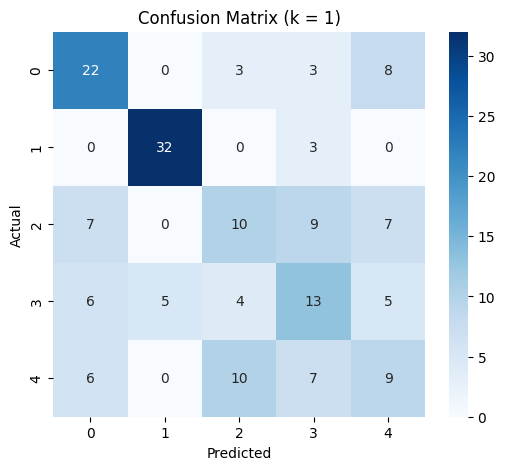

Test Accuracy: 0.5088757396449705


In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
y_pred = best_knn.predict(X_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (k = 1)")
plt.show()

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

The confusion matrix shows an overall test accuracy of approximately 50.9%. Mine type 2 is classified with high accuracy (32 correct predictions), suggesting that its feature values are more distinct from other classes. In contrast, mine types 3, 4, and 5 are frequently confused with one another, indicating substantial overlap in voltage, height, and soil characteristics. Mine type 1 is moderately well classified but is sometimes misidentified as type 5. Overall, the model struggles to clearly separate several mine types due to overlapping feature distributions.

Although the model achieves moderate overall accuracy (approximately 51%), the confusion matrix reveals substantial misclassification among several mine types, particularly types 3, 4, and 5. In a real-world setting, such errors could have serious safety implications, as different mine types may require different removal procedures. Therefore, this model should not be used as a fully automated decision tool. Instead, it should serve as a decision-support system, providing preliminary classifications while allowing trained experts to review uncertain cases. In situations where predictions are ambiguous, it would be safer to treat the mine as the highest-risk type to minimize potential harm.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [9]:
import pandas as pd

# Load data
df = pd.read_csv("./data/USA_cars_datasets.csv")

# Keep only relevant columns
df = df[['price', 'year', 'mileage']]

# Look at head and shape
print(df.head())
print("Shape:", df.shape)

# Check for missing values
print("\nMissing values:")
print(df.isna().sum())

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
Shape: (2499, 3)

Missing values:
price      0
year       0
mileage    0
dtype: int64


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['year', 'mileage']] = scaler.fit_transform(df[['year', 'mileage']])

df.head()

,price,year,mileage
0,6300,0.744681,0.269287
1,2899,0.808511,0.187194
2,5350,0.957447,0.038892
3,25000,0.872340,0.063016
4,27700,0.957447,0.006537


In [11]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df[['year', 'mileage']]
y = df['price']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # 20% for testing
    random_state=42    # reproducibility
)

# Check sizes
print("Training size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Training size: 1999
Test size: 500


k = 3, MSE = 148065935.51955554


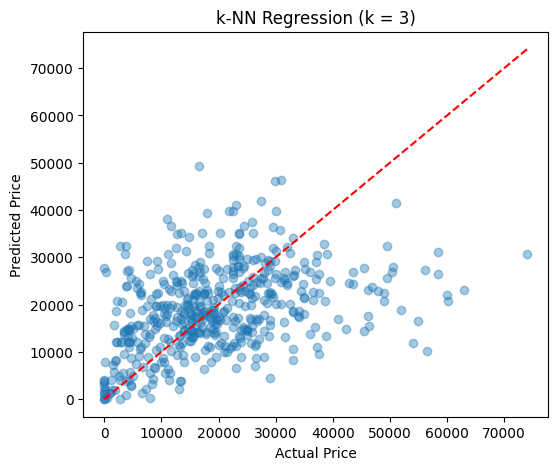

k = 10, MSE = 117399126.10604002


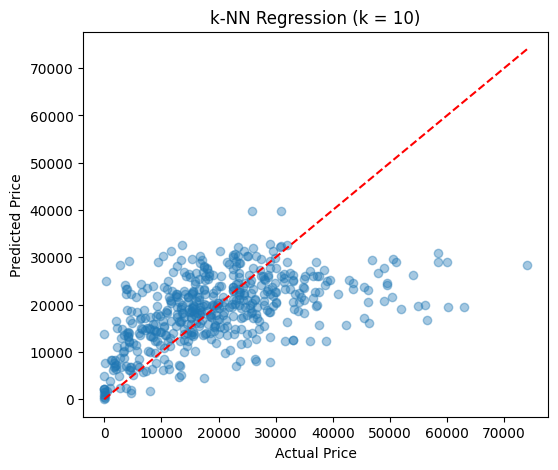

k = 25, MSE = 112576160.82390079


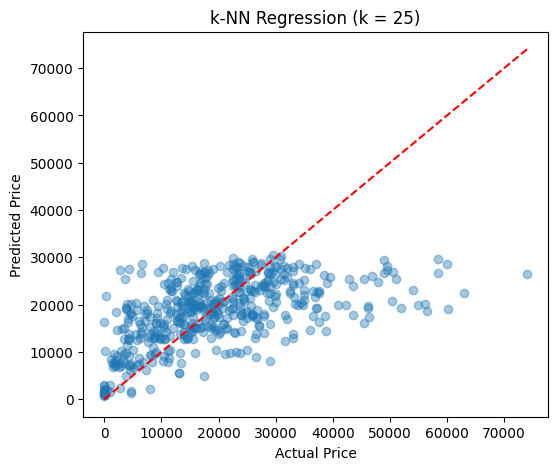

k = 50, MSE = 110202549.3014296


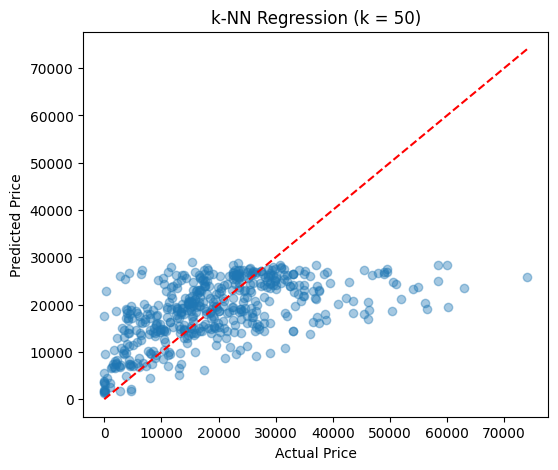

k = 100, MSE = 112253702.9700672


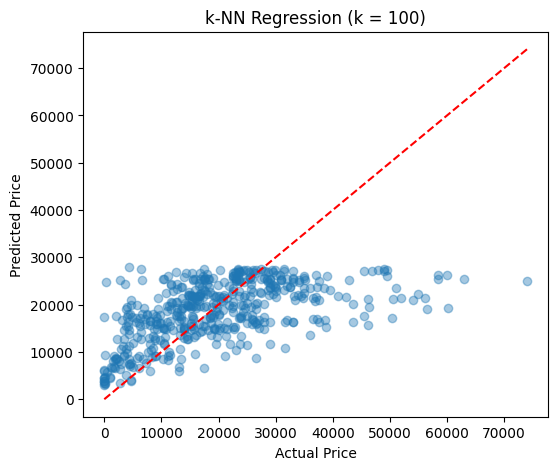

k = 300, MSE = 114496092.28682345


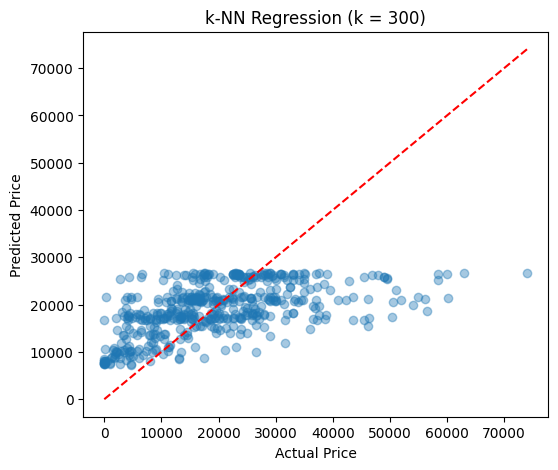

In [12]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

k_values = [3, 10, 25, 50, 100, 300]
mse_results = {}

for k in k_values:
    # Build model
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Compute MSE
    mse = mean_squared_error(y_test, y_pred)
    mse_results[k] = mse

    print(f"k = {k}, MSE = {mse}")

    # Scatterplot
    plt.figure(figsize=(6,5))
    plt.scatter(y_test, y_pred, alpha=0.4)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"k-NN Regression (k = {k})")

    # Diagonal reference line
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')

    plt.show()

The optimal value of k is 50, as it produces the lowest test mean squared error (approximately 110,202,549). For smaller values of k, the model exhibits higher variance and larger prediction errors. For larger values of k, the model begins to underfit and MSE increases again. Thus, k=50 provides the best bias–variance tradeoff.

As k varied, the behavior of the predicted versus actual price plots changed noticeably. For small values of k (such as k=3), the model exhibited overfitting: predictions were highly scattered and closely followed local fluctuations in the data, indicating high variance. As k increased, the predictions became smoother and less sensitive to individual observations. For very large values of k (such as k=300), the model showed clear underfitting, with predictions shrinking toward the overall mean price and failing to capture variation in high- and low-priced vehicles. The optimal k=50 balances overfitting and underfitting by minimizing test mean squared error and producing predictions that align more closely with the diagonal reference line.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [38]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/airbnb_hw.csv")

# Keep only needed columns
df = df.loc[:, ["Review Scores Rating", "Price", "Beds"]]

df.head()

# Clean Price/Beds so sklearn can use them
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)   # removes $ and commas
    .str.strip()
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Beds"]  = pd.to_numeric(df["Beds"], errors="coerce")

# sanity check
print(df["Price"].head(10).tolist())
print(df[["Price","Beds"]].dtypes)

[145, 37, 28, 199, 549, 149, 250, 90, 270, 290]
Price      int64
Beds     float64
dtype: object


In [39]:
# STEP 2 (UPDATED): split into missing vs complete ratings
df_missing = df.loc[df["Review Scores Rating"].isnull()].copy()
df_complete = df.loc[~df["Review Scores Rating"].isnull()].copy()

df_missing.head()

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
13,NaN,68,1.0


In [40]:
# STEP 3 (UPDATED): drop any remaining NA rows from complete cases
df_complete = df_complete.dropna(axis=0, how="any")

df_complete.head()

,Review Scores Rating,Price,Beds
4,96.0,549,3.0
5,100.0,149,1.0
6,100.0,250,1.0
7,94.0,90,1.0
8,90.0,270,2.0


In [41]:
# STEP 4 (UPDATED): choose k via train/test split and minimize SSE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

X = df_complete[["Price", "Beds"]]
y = df_complete["Review Scores Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

k_values = range(1, 31)
sse_list = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    sse = np.sum((y_test - y_pred) ** 2)
    sse_list.append(sse)

best_k = list(k_values)[np.argmin(sse_list)]
best_k

30

I chose k = 30 because, after a train/test split and testing values of k from 1 to 30, k=30 produced the lowest SSE on the test set.

In [44]:
# STEP 5 (FIXED): Predict missing ratings (handle NaNs in Price/Beds)

from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# 1) Training data: must have Price, Beds, and Rating all present
train_df = df_complete.dropna(subset=["Price", "Beds", "Review Scores Rating"]).copy()

X_full = train_df[["Price", "Beds"]]
y_full = train_df["Review Scores Rating"]

# 2) Missing-rating rows: only predict where Price and Beds are present
miss_df = df_missing.copy()
miss_has_features = miss_df.dropna(subset=["Price", "Beds"]).copy()

X_missing = miss_has_features[["Price", "Beds"]]

# 3) Fit + predict
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_full, y_full)

predicted_ratings = final_model.predict(X_missing)

# 4) Put predictions back into df_missing (align by index)
df_missing["Predicted Rating"] = np.nan
df_missing.loc[miss_has_features.index, "Predicted Rating"] = predicted_ratings

df_missing.head()

,Review Scores Rating,Price,Beds,Predicted Rating
0,NaN,145,1.0,94.766667
1,NaN,37,1.0,90.033333
2,NaN,28,1.0,85.566667
3,NaN,199,3.0,89.566667
13,NaN,68,1.0,91.733333


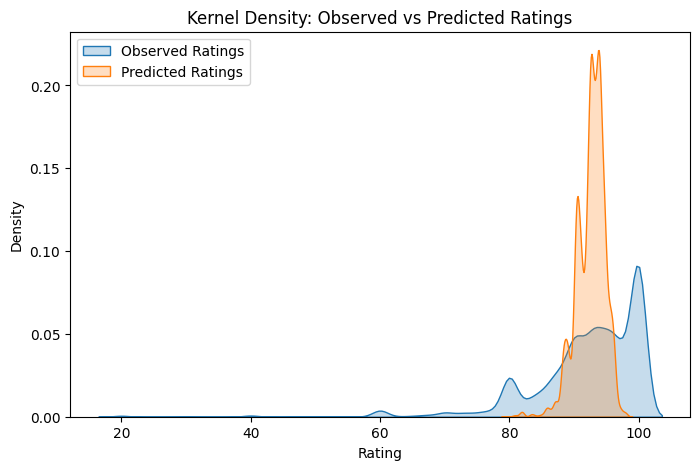

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Training ratings
sns.kdeplot(
    train_df["Review Scores Rating"],
    label="Observed Ratings",
    fill=True
)

# Predicted ratings
sns.kdeplot(
    df_missing["Predicted Rating"].dropna(),
    label="Predicted Ratings",
    fill=True
)

plt.legend()
plt.title("Kernel Density: Observed vs Predicted Ratings")
plt.xlabel("Rating")
plt.show()

The predicted ratings are much more concentrated than the observed ratings. While the observed ratings show a wider spread and include lower values, the predicted ratings are tightly clustered around the 90–95 range. This occurs because kNN regression averages neighboring observations, which reduces variability and pulls predictions toward the mean. As a result, the imputed ratings have lower variance than the original ratings.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)

In [13]:
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


7 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 254 254 241 198 198 198 198 198 198 19

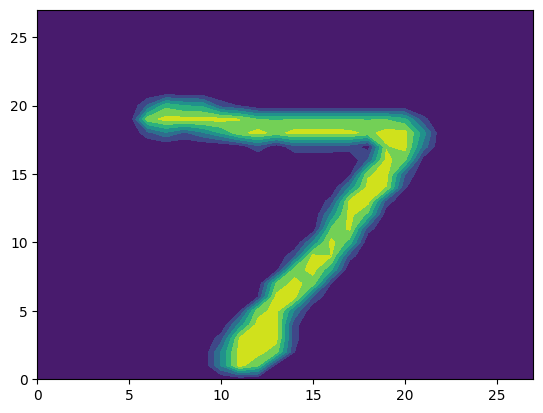

2 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 116 125 171 255 255 150  93   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 169 253 253 253 253 253 253 218  30   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169 253 253 253 213 142 176 253 253 122   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  52 250 253 210  32  12   0   6 206 253 140   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  77 251 210  25   0   0   0 122 248 253  65   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  31  18   0   0   0   0 209 253 253  65   

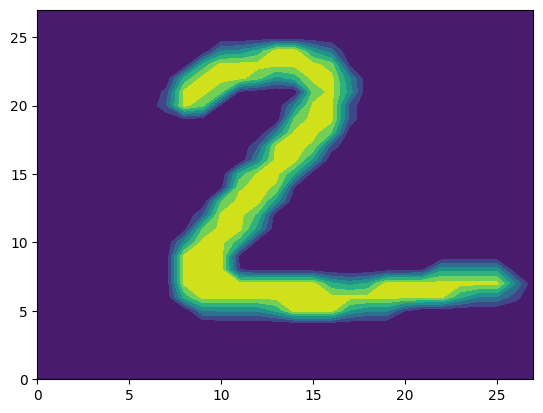

1 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38 254 109   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  87 252  82   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 135 241   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  45 244 150   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  84 254  63   

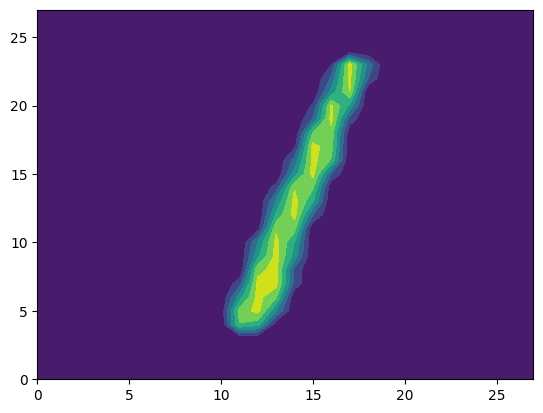

0 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  11 150 253 202  31   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  37 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  21 197 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 110 190 251 251 251 253 169 109  62   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 253 251 251 251 251 253 251 251 22

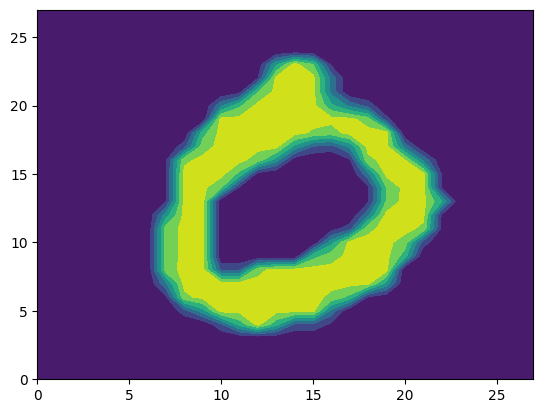

4 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  50 224   0   0   0   0   0   0   0  70  29   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 121 231   0   0   0   0   0   0   0 148 168   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   4 195 231   0   0   0   0   0   0   0  96 210  11   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  69 252 134   0   0   0   0   0   0   

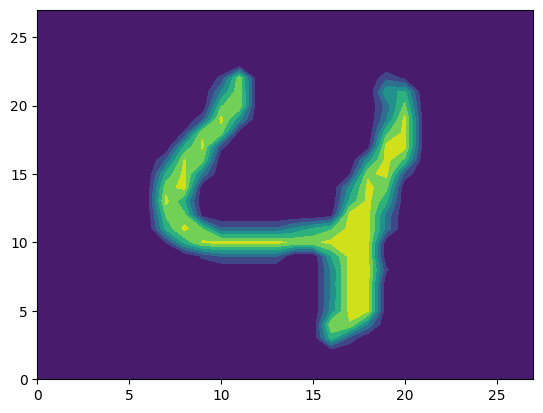

In [14]:
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()